In [ ]:
!pip install -U torch torchvision joblib pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 61.6 MB/s eta 0:00:00
  Attempting uninstall: pillow
    Found existing installation: pillow 11.3.0
    Uninstalling pillow-11.3.0:
      Successfully uninstalled pillow-11.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.1 which is incompatible.


In [ ]:
import torch
import torchvision as tv
import numpy as np
import joblib
import os

from torchvision import transforms, datasets
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
MODEL_PATH = "/content/drive/MyDrive/saved_models/EfficientNetB1_80:20_svm.joblib"
DATASET_PATH = "/content/drive/MyDrive/datasets/IQ-OTHNCCD"

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Device:", device)

Device: cpu


In [ ]:
transform = transforms.Compose([
    transforms.Resize((240,240)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])

In [ ]:
net = tv.models.efficientnet_b1(
    weights=tv.models.EfficientNet_B1_Weights.IMAGENET1K_V1
).to(device).eval()

feature_extractor = torch.nn.Sequential(
    net.features,
    net.avgpool,
    torch.nn.Flatten()
)

print("Feature extractor loaded")

Downloading: "https://download.pytorch.org/models/efficientnet_b1_rwightman-bac287d4.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1_rwightman-bac287d4.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 47.8MB/s]


Feature extractor loaded


In [ ]:
ds = datasets.ImageFolder(DATASET_PATH)

CLASS_NAMES = ds.classes

print("Class names:", CLASS_NAMES)

Class names: ['Bengin cases', 'Malignant cases', 'Normal cases']


In [ ]:
clf = joblib.load(MODEL_PATH)

print("Classifier loaded successfully")

Classifier loaded successfully


In [ ]:
def predict_ct_image(image_path):

    img = Image.open(image_path).convert("RGB")

    img_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        features = feature_extractor(img_tensor)
        features = features.cpu().numpy()

    probs = clf.predict_proba(features)[0]

    pred_idx = np.argmax(probs)

    predicted_class = CLASS_NAMES[pred_idx]
    confidence = probs[pred_idx]

    plt.imshow(img)
    plt.axis("off")
    plt.title(
        f"Prediction: {predicted_class}\nConfidence: {confidence*100:.2f}%"
    )
    plt.show()

    return predicted_class, confidence

In [ ]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

Saving Bengin case (14).jpg to Bengin case (14).jpg


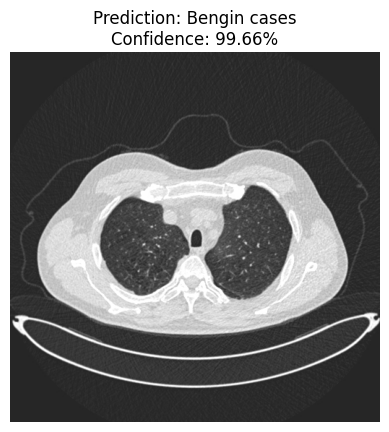

Final Result
------------
Class : Bengin cases
Confidence : 99.66 %


In [ ]:
pred_class, conf = predict_ct_image(image_path)

print("Final Result")
print("------------")
print("Class :", pred_class)
print("Confidence :", round(conf*100,2),"%")